In [23]:
#task 1
#importing required libraries
import pandas as pd


In [7]:
#loading data 
df = pd.read_csv(r"C:\Users\KALPANA\Downloads\housepricing\Housing.csv")

In [8]:
#accessing data displaying 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
#checking last 10 rows
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [10]:
#checking how many rows and columns are there
print(f"Dataset Shape: {df.shape}")

#displayed output (rows,column)

Dataset Shape: (545, 13)


In [11]:
# Identify which column is the target (Price) and which are features

print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


target variable : price 
features :area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus

In [12]:
#checking for any missing values

print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Data is cleaned and no missing data

In [ ]:
#Task 2
#Handle missing values
No misisng values

In [14]:
#Removing dupilicate rows
print(f"Duplicate rows Found: {df.duplicated().sum()}")

Duplicate rows Found: 0


No duplicates found

In [15]:
# Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

df.head(3)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished


In [17]:
# Apply One-Hot Encoding to all categorical text columns
df_clean = pd.get_dummies(df, drop_first=True)
df_clean.head(3)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False


In [19]:
#converting True/false columns into 1 and 0
df_clean = df_clean.astype(int)
df_clean.head(3)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0


In [ ]:
#keep only the necessary coulums for the analysis
no unwanted columns

In [22]:
#task 3 model Building 
 #Split the data into training and test sets (80/20)
#seperate dataset into X and Y

#Y as target variable : price
Y= df_clean['price']

#X as everything except price
X= df_clean.drop(columns=['price'])



In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state= 42)

#check the size of our splits
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 436 rows
Testing set size: 109 rows


In [28]:
#Train a linear Regression model to predict house price"
from sklearn.linear_model import LinearRegression

# 1. Initialize the Linear Regression model
model = LinearRegression()

# 2. Train the model using the training data
model.fit(X_train, Y_train)

print("Model training complete!")

Model training complete!


In [31]:
# Evaluate it using MAE, RMSE, and R² Score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Get predictions from the model using the test data
Y_pred = model.predict(X_test)

# 2. Calculate the evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

# 3. Print the results
print("---liner Regression--")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

---liner Regression--
Mean Absolute Error (MAE): 970,043.40
Root Mean Squared Error (RMSE): 1,324,506.96
R-squared (R2) Score: 0.6529


In [32]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, Y_train)

# 3. Get predictions
Y_pred_rf = rf_model.predict(X_test)

# 4. Calculate metrics for Random Forest
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
r2_rf = r2_score(Y_test, Y_pred_rf)

# 5. Print the Random Forest Results
print("--- Random Forest Regressor Results ---")
print(f"Mean Absolute Error (MAE): {mae_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:,.2f}")
print(f"R-squared (R2) Score: {r2_rf:.4f}")

--- Random Forest Regressor Results ---
Mean Absolute Error (MAE): 1,021,546.04
Root Mean Squared Error (RMSE): 1,400,565.97
R-squared (R2) Score: 0.6119


comparing Liner regression and Random forest regressor
Metric                      Linear Regression    Random Forest Regressor
MAE (Lower is better)         "970,043.40"           "1,021,546.04"
RMSE (Lower is better)        "1,324,506.96"         "1,400,565.97"
R2 Score (Higher is better)     0.6529                  0.6119

liner regression model works better than randomn forest model
### reason

1. **Linear Relationships:** Core housing features like size (`area`), number of `bedrooms`, and `bathrooms` scale very predictably and linearly with market price. Linear Regression is perfectly built to exploit these straight-line relationships.
2. **Dataset Size:** Random Forest is a highly complex model that requires a massive amount of data to map out its "decision trees" properly. With a small training dataset (436 rows), it struggled to find deep patterns and slightly overfit, leading to a lower test score (`0.6119` vs. Linear Regression's `0.6529`).



In [36]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


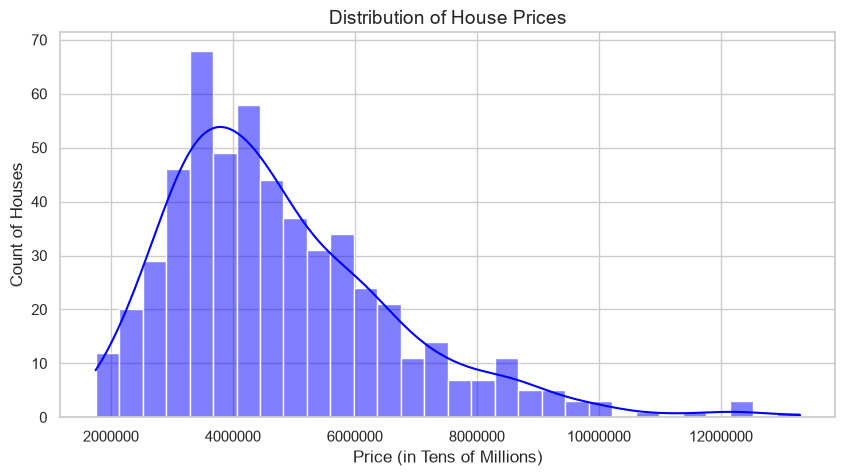

In [38]:
#task 4 
## Chart 1: Histogram showing the distribution of house prices

import matplotlib.pyplot as plt
import seaborn as sea

# Set a clean visual theme
sea.set_theme(style="whitegrid")

# Create the figure size
plt.figure(figsize=(10, 5))

# Plot the histogram with a Kernel Density Estimate (KDE) line
sea.histplot(df_clean['price'], kde=True, color='blue', bins=30)

# Add titles and labels
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price (in Tens of Millions)', fontsize=12)
plt.ylabel('Count of Houses', fontsize=12)

# Fix formatting so numbers don't show up in scientific notation (like 1e7)
plt.ticklabel_format(style='plain', axis='x') 

# Display the chart
plt.show()

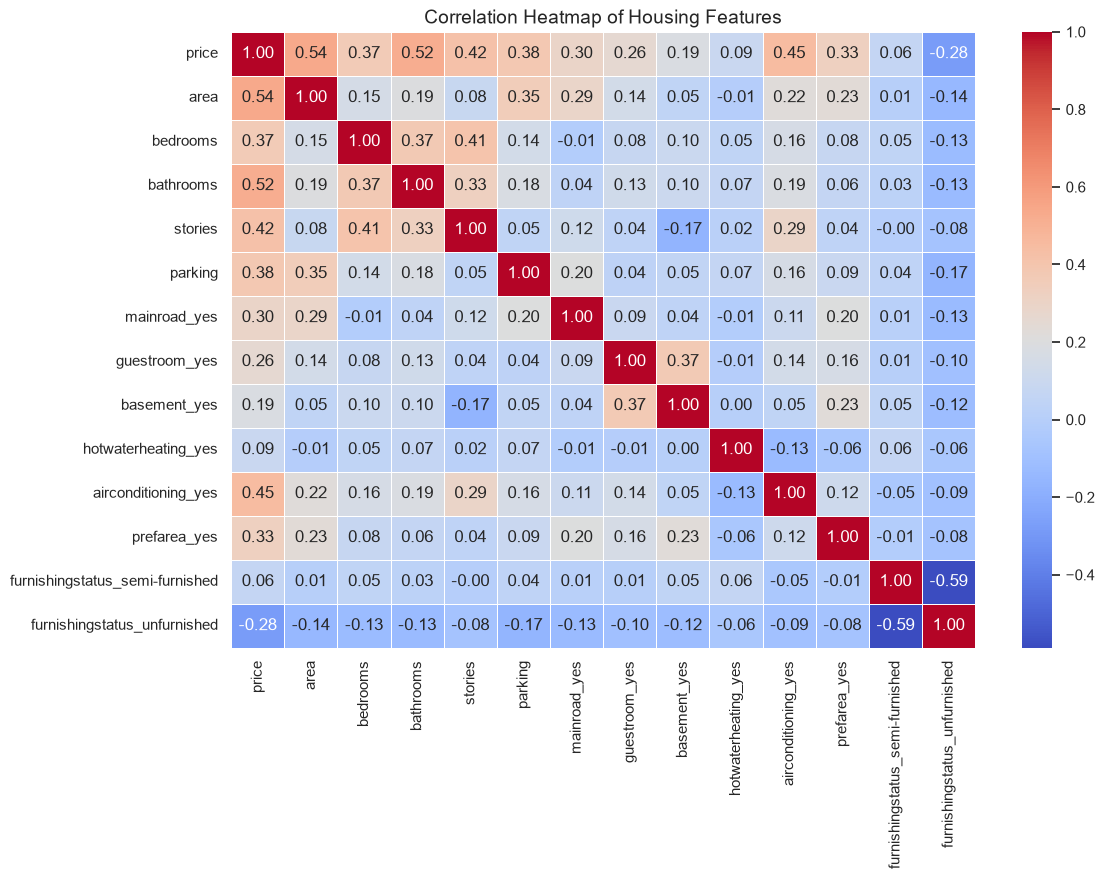

In [42]:
#Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12, 8))

correlation_matrix = df_clean.corr()

# Draw the heatmap
sea.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features', fontsize=14)
plt.show()


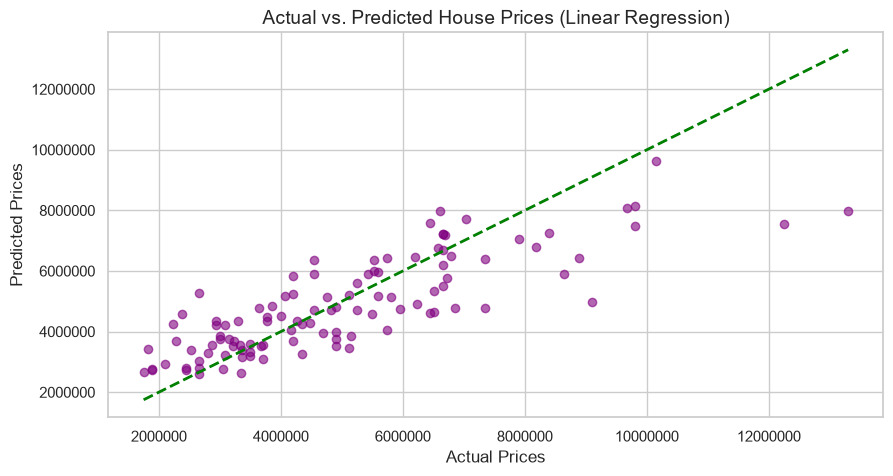

In [45]:
#Chart 3: A chart of your own choice
# --- CHART 3: Actual vs. Predicted Prices ---
plt.figure(figsize=(10, 5))

# Plot actual prices against what the model predicted
plt.scatter(Y_test, Y_pred, alpha=0.6, color='purple')

# Draw a perfect diagonal line for reference (where actual equals predicted)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--', lw=2, color='green')

# Add titles and labels
plt.title('Actual vs. Predicted House Prices (Linear Regression)', fontsize=14)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)

# Fix formatting to avoid scientific notation
plt.ticklabel_format(style='plain', axis='both')

plt.show()

# Task 5 — Insights & Summary

1) What drives prices most?
   Property size (`area`), number of `bathrooms`, and having  `airconditioning` are the biggest factors behind higher house prices.

  
2) Which model won?
   Linear Regression was the winner with an R² score of **0.6529** (explaining 65.3% of the price changes).

   Why did it win? Real estate prices usually scale in a straight, predictable line. The Random Forest model was too complex for our small dataset (436 rows) and slightly overfit, leading to a lower score (**0.6119**).

  
3) Data Surprise:
    Having a `basement` or `mainroad` access mattered much less to the final price than expected.

  
4) Business Takeaway:
    To maximize property value, focus on increasing the livable square footage (`area`) and adding internal upgrades like air conditioning or extra bathrooms.